# Project Documentation

## Data Overview

The dataset is **multi-label**, meaning each image can belong to multiple labels. Here's the workflow I followed to preprocess and analyze the data:

1. **Unique Labels Analysis**  
   - First, I examined the dataset to identify all **unique labels**.
   - Then, I performed **one-hot encoding** for each label, creating a separate column for every label.
   - Each image now has a corresponding row showing which labels it belongs to.

2. **Label Frequency**  
   - I calculated the **frequency of each label** to check how many times it appears across the dataset.
   - This helped assess whether the dataset is **balanced** or not.

3. **Removing Rare Columns**  
   - Two columns were extremely rare (appeared only once): `'Malaligned'` and `'Retained root'`.  
   - These columns were **removed** from the dataset to avoid sparsity issues.

4. **Images per Number of Labels**  
   - I analyzed the dataset to count how many images have:  
     - 1 label  
     - 2 labels  
     - 3 labels  
     - … up to 10 labels  
   - This provides insight into **label combinations per image**.

5. **Label Correlation Analysis**  
   - I computed the **correlation between labels** to see which labels tend to appear together.

6. **Label Combinations**  
   - I generated **combinations of labels** to track how often specific pairs or groups of labels appear together.  
   - This gives a detailed view of **label co-occurrence patterns** in the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"E:\grad_project\Dental_X-ray panoramic\Data Dental X_Ray_Panoramic\train\train_labels.csv")
df.head()

,image_name,labels
0,1452650000-jpg_png_jpg.rf.1d73675b99c6c1afe90c...,Filling|impacted tooth
1,3975890000-jpg_png_jpg.rf.1d1b03af3734eba73e9d...,Filling|Root Canal Treatment|impacted tooth
2,4054820000-jpg_png_jpg.rf.1d4a4d0a6fd081280376...,Filling|impacted tooth
3,3794860000-jpg_png_jpg.rf.1cb8e683ddd8a1131d0f...,Crown|Filling|Missing teeth|Root Canal Treatme...
4,3867370000-jpg_png_jpg.rf.1d45c92826c5c0473400...,Filling|impacted tooth


In [3]:
all_labels = df['labels']
split_labels = all_labels.str.split('|')
flattened = [label.strip() for sublist in split_labels for label in sublist]
unique_labels = sorted(set(flattened))
len(unique_labels)

13

In [4]:
unique_labels

['Caries',
 'Crown',
 'Filling',
 'Implant',
 'Malaligned',
 'Mandibular Canal',
 'Missing teeth',
 'Periapical lesion',
 'Retained root',
 'Root Canal Treatment',
 'Root Piece',
 'impacted tooth',
 'maxillary sinus']

In [5]:
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
label_to_index

{'Caries': 0,
 'Crown': 1,
 'Filling': 2,
 'Implant': 3,
 'Malaligned': 4,
 'Mandibular Canal': 5,
 'Missing teeth': 6,
 'Periapical lesion': 7,
 'Retained root': 8,
 'Root Canal Treatment': 9,
 'Root Piece': 10,
 'impacted tooth': 11,
 'maxillary sinus': 12}

In [6]:
def encode_labels(label_string, label_to_index):
    vector = np.zeros(len(label_to_index), dtype=int)
    labels = label_string.split('|')

    for label in labels:
        idx = label_to_index[label]
        vector[idx] = 1

    return vector

In [7]:
encode_labels(
    "Caries|Filling|impacted tooth",
    label_to_index
)

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [8]:
df['labels'] = df['labels'].str.split('|')

# One-vs-All encoding
for label in unique_labels:
    df[label] = df['labels'].apply(lambda x: 1 if label in x else 0)

df = df.drop(columns=['labels'])

[3594, 3238, 1910, 1610, 1276, 1018, 810, 482, 280, 262, 194, 2, 2]


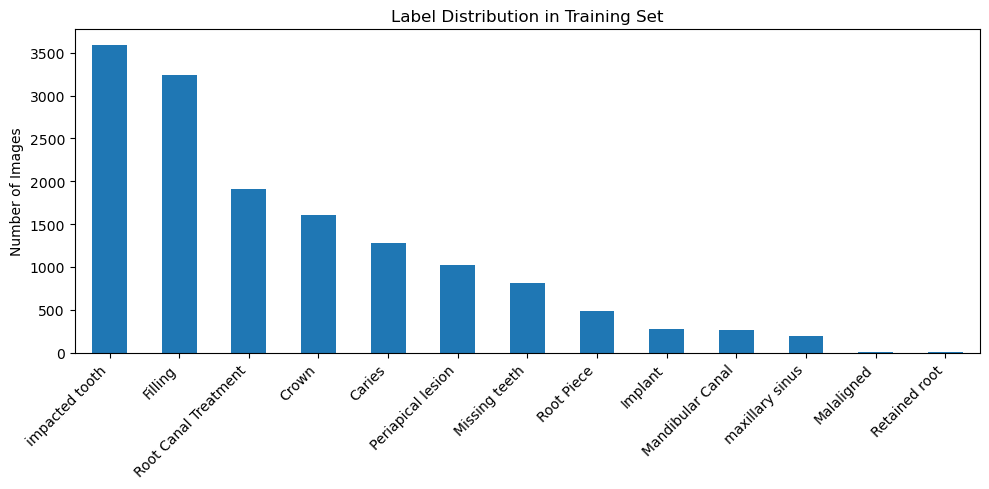

In [9]:
label_counts = df[unique_labels].sum().sort_values(ascending=False)
print(list(label_counts))
plt.figure(figsize=(10,5))
label_counts.plot(kind='bar')
plt.title("Label Distribution in Training Set")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
print(df.shape)

(4772, 14)


In [11]:
df = df[(df['Malaligned'] == 0) & (df['Retained root'] == 0)]

df = df.drop(columns=['Malaligned',"Retained root"])
df.to_csv("train_cleaned.csv", index=False)
print(df.shape)

(4768, 12)


In [12]:
df['image_name'].duplicated().sum()


np.int64(0)

1      796
2     1374
3      730
4      946
5      554
6      250
7       82
8       32
9        2
10       2
Name: count, dtype: int64


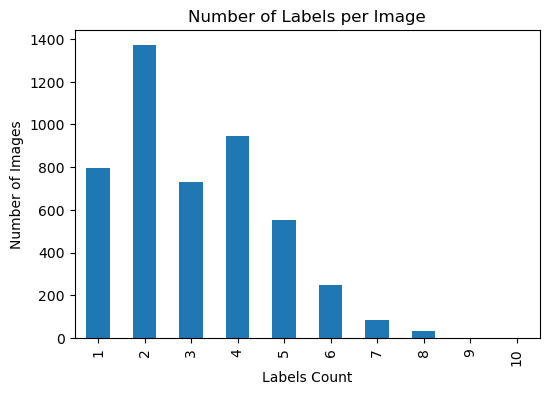

In [13]:
labels_per_image = df.iloc[:, 1:].sum(axis=1)
print(labels_per_image.value_counts().sort_index())

plt.figure(figsize=(6,4))
labels_per_image.value_counts().sort_index().plot(kind='bar')
plt.title("Number of Labels per Image")
plt.xlabel("Labels Count")
plt.ylabel("Number of Images")
plt.show()


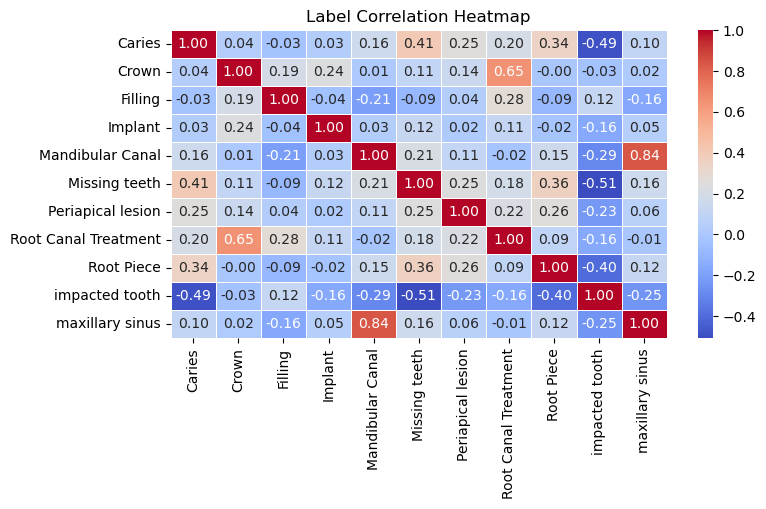

In [14]:
plt.figure(figsize=(8,4))
sns.heatmap(df.iloc[:, 1:].corr(), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Label Correlation Heatmap")
plt.show()


In [15]:
comb = df.iloc[:, 1:].apply(lambda x: tuple(x[x==1].index), axis=1)

top_combinations = comb.value_counts().head(20)

print(top_combinations)

(Filling, impacted tooth)                                                    1034
(impacted tooth,)                                                             624
(Crown, Filling, Root Canal Treatment, impacted tooth)                        464
(Crown, Filling, Periapical lesion, Root Canal Treatment, impacted tooth)     142
(Filling, Root Canal Treatment, impacted tooth)                               124
(Filling, Periapical lesion, impacted tooth)                                  106
(Crown, Filling, impacted tooth)                                               90
(Caries, Filling, impacted tooth)                                              88
(Caries, Crown, Filling, Root Canal Treatment, impacted tooth)                 68
(Filling,)                                                                     66
(Crown, Root Canal Treatment, impacted tooth)                                  66
(Caries, impacted tooth)                                                       60
(Periapical lesi